# Análise das despesas públicas de Rondônia

Este notebook analisa as despesas por função e subfunção do Estado de Rondônia, usando a DCA do SICONFI entre 2015 e 2025, com destaque para Saúde e Educação. A análise é descritiva e não atribui causalidade às alterações observadas.

## 2. Nomes efetivos das colunas

Nesta base, a API não retorna colunas separadas chamadas função e subfunção. A classificação está em `conta`: função usa `NN - Nome` e subfunção usa `NN.NNN - Nome`. O estágio está em `coluna` e o valor em `valor`. A verificação abaixo evita inventar nomes de colunas.

## 3. Preparação da base

As expressões regulares abaixo identificam automaticamente as classificações presentes na base. Nenhuma lista manual de subfunções é criada.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")

ARQUIVO_BASE = Path("DCA_RO_2015_2025.xlsx")
ARQUIVO_ANALISE = Path("Analise_Despesas_RO_2015_2025.xlsx")
ANO_INICIAL, ANO_FINAL = 2015, 2025
ESTAGIO_PRINCIPAL = "Despesas Empenhadas"

df_bruta = pd.read_excel(ARQUIVO_BASE, sheet_name="DCA_Anexo_IE")
print("Colunas retornadas:", df_bruta.columns.tolist())
display(df_bruta.head())
print("Estágios:")
display(df_bruta["coluna"].value_counts(dropna=False))
print("Exemplos de classificações:")
display(df_bruta[["cod_conta", "conta"]].drop_duplicates().head(25))

df = df_bruta.copy()
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
df["ano"] = pd.to_numeric(df["ano_consulta"], errors="coerce").astype("Int64")
df["conta"] = df["conta"].astype("string")
padrao_subfuncao = r"^\s*(\d{2})\.(\d{3})\s*-\s*(.+?)\s*$"
padrao_funcao = r"^\s*(\d{2})\s*-\s*(.+?)\s*$"
sub = df["conta"].str.extract(padrao_subfuncao)
fun = df["conta"].str.extract(padrao_funcao)
df["codigo_funcao"] = sub[0].fillna(fun[0])
df["codigo_subfuncao"] = sub[1]
df["funcao"] = fun[1]
df["subfuncao"] = sub[2]
df["nivel"] = np.select([df["codigo_subfuncao"].notna(), df["codigo_funcao"].notna()], ["Subfunção", "Função"], default="Outros")
print("Ausentes por coluna:")
display(df.isna().sum().sort_values(ascending=False).head(15))
print("Duplicados exatos:", int(df.duplicated().sum()))
display(df["nivel"].value_counts())

Colunas retornadas: ['exercicio', 'instituicao', 'cod_ibge', 'uf', 'anexo', 'rotulo', 'coluna', 'cod_conta', 'conta', 'valor', 'populacao', 'ano_consulta']


,exercicio,instituicao,cod_ibge,uf,anexo,rotulo,coluna,cod_conta,conta,valor,populacao,ano_consulta
0,2015,Governo do Estado de Rondônia,11,RO,DCA-Anexo I-E,NaN,Despesas Empenhadas,TotalDespesas,Despesas (Exceto Intraorçamentárias),"6,017,358,278.37",1748531,2015
1,2015,Governo do Estado de Rondônia,11,RO,DCA-Anexo I-E,NaN,Despesas Empenhadas,TotalDespesas,01 - Legislativa,"283,277,874.36",1748531,2015
2,2015,Governo do Estado de Rondônia,11,RO,DCA-Anexo I-E,NaN,Despesas Empenhadas,TotalDespesas,01.031 - Ação Legislativa,"11,152,992.72",1748531,2015
3,2015,Governo do Estado de Rondônia,11,RO,DCA-Anexo I-E,NaN,Despesas Empenhadas,TotalDespesas,01.032 - Controle Externo,"294,585.11",1748531,2015
4,2015,Governo do Estado de Rondônia,11,RO,DCA-Anexo I-E,NaN,Despesas Empenhadas,TotalDespesas,01.999 - Demais Subfunções Legislativa,"271,830,296.53",1748531,2015


Estágios:


coluna
Despesas Empenhadas                            1161
Despesas Liquidadas                            1158
Despesas Pagas                                 1156
Inscrição de Restos a Pagar Não Processados     867
Inscrição de Restos a Pagar Processados         684
Inscrição de RP Não Processados                 155
Inscrição de RP Processados                     137
Name: count, dtype: int64

Exemplos de classificações:


,cod_conta,conta
0,TotalDespesas,Despesas (Exceto Intraorçamentárias)
1,TotalDespesas,01 - Legislativa
2,TotalDespesas,01.031 - Ação Legislativa
3,TotalDespesas,01.032 - Controle Externo
4,TotalDespesas,01.999 - Demais Subfunções Legislativa
5,TotalDespesas,02 - Judiciária
6,TotalDespesas,02.061 - Ação Judiciária
7,TotalDespesas,02.999 - Demais Subfunções Judiciária
8,TotalDespesas,03 - Essencial à Justiça
9,TotalDespesas,03.091 - Defesa da Ordem Jurídica


Ausentes por coluna:


funcao              4126
codigo_subfuncao    1907
subfuncao           1907
rotulo               826
codigo_funcao        715
exercicio              0
instituicao            0
cod_ibge               0
uf                     0
anexo                  0
valor                  0
conta                  0
cod_conta              0
coluna                 0
ano                    0
dtype: int64

Duplicados exatos: 0


nivel
Subfunção    3411
Função       1192
Outros        715
Name: count, dtype: int64

In [2]:
df_analise = df.loc[(df["coluna"] == ESTAGIO_PRINCIPAL) & df["ano"].between(ANO_INICIAL, ANO_FINAL) & df["valor"].notna()].copy()
df_funcoes = df_analise.loc[df_analise["nivel"] == "Função"].copy()
df_funcoes = df_funcoes.loc[~df_funcoes["conta"].str.contains("Intraorçamentárias", case=False, na=False)]
totais_ano = df_funcoes.groupby("ano", as_index=False)["valor"].sum().rename(columns={"valor":"total_despesas"})
funcao_ano = df_funcoes.groupby(["ano","codigo_funcao","funcao"], as_index=False)["valor"].sum().rename(columns={"valor":"despesa"})
funcao_ano = funcao_ano.merge(totais_ano, on="ano")
funcao_ano["participacao_pct"] = 100 * funcao_ano["despesa"] / funcao_ano["total_despesas"]
funcao_ano = funcao_ano.sort_values(["codigo_funcao","ano"])
funcao_ano["variacao_nominal"] = funcao_ano.groupby("codigo_funcao")["despesa"].diff()
funcao_ano["variacao_pct"] = 100 * funcao_ano.groupby("codigo_funcao")["despesa"].pct_change()
extremos = funcao_ano.pivot_table(index=["codigo_funcao","funcao"], columns="ano", values="despesa", aggfunc="sum").reset_index()
extremos = extremos.rename(columns={ANO_INICIAL:"despesa_2015", ANO_FINAL:"despesa_2025"})
funcao_ano = funcao_ano.merge(extremos, on=["codigo_funcao","funcao"], how="left")
funcao_ano["crescimento_acumulado_pct"] = 100 * (funcao_ano["despesa_2025"] / funcao_ano["despesa_2015"] - 1)
participacoes = funcao_ano.pivot_table(index=["codigo_funcao","funcao"], columns="ano", values="participacao_pct", aggfunc="sum").reset_index()
comparacao_funcoes = extremos.copy()
comparacao_funcoes["participacao_2015"] = participacoes[ANO_INICIAL]
comparacao_funcoes["participacao_2025"] = participacoes[ANO_FINAL]
comparacao_funcoes["variacao_participacao_p.p."] = comparacao_funcoes["participacao_2025"] - comparacao_funcoes["participacao_2015"]
comparacao_funcoes["crescimento_2015_2025_pct"] = 100 * (comparacao_funcoes["despesa_2025"] / comparacao_funcoes["despesa_2015"] - 1)
display(funcao_ano.head())
display(comparacao_funcoes)

,ano,codigo_funcao,funcao,despesa,total_despesas,participacao_pct,variacao_nominal,variacao_pct,despesa_2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,despesa_2025,crescimento_acumulado_pct
0,2015,01,Legislativa,"283,277,874.36","6,017,358,278.37",4.71,NaN,NaN,"283,277,874.36","333,062,980.94","322,696,837.81","349,509,011.76","329,414,773.14","324,667,726.43","373,096,359.19","452,324,149.25","547,440,762.07","683,466,258.35","806,868,109.76",184.83
1,2016,01,Legislativa,"333,062,980.94","6,253,210,812.50",5.33,"49,785,106.58",17.57,"283,277,874.36","333,062,980.94","322,696,837.81","349,509,011.76","329,414,773.14","324,667,726.43","373,096,359.19","452,324,149.25","547,440,762.07","683,466,258.35","806,868,109.76",184.83
2,2017,01,Legislativa,"322,696,837.81","6,813,099,270.68",4.74,"-10,366,143.13",-3.11,"283,277,874.36","333,062,980.94","322,696,837.81","349,509,011.76","329,414,773.14","324,667,726.43","373,096,359.19","452,324,149.25","547,440,762.07","683,466,258.35","806,868,109.76",184.83
3,2018,01,Legislativa,"349,509,011.76","7,243,527,767.38",4.83,"26,812,173.95",8.31,"283,277,874.36","333,062,980.94","322,696,837.81","349,509,011.76","329,414,773.14","324,667,726.43","373,096,359.19","452,324,149.25","547,440,762.07","683,466,258.35","806,868,109.76",184.83
4,2019,01,Legislativa,"329,414,773.14","7,277,890,974.15",4.53,"-20,094,238.62",-5.75,"283,277,874.36","333,062,980.94","322,696,837.81","349,509,011.76","329,414,773.14","324,667,726.43","373,096,359.19","452,324,149.25","547,440,762.07","683,466,258.35","806,868,109.76",184.83


ano,codigo_funcao,funcao,despesa_2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,despesa_2025,participacao_2015,participacao_2025,variacao_participacao_p.p.,crescimento_2015_2025_pct
0,01,Legislativa,"283,277,874.36","333,062,980.94","322,696,837.81","349,509,011.76","329,414,773.14","324,667,726.43","373,096,359.19","452,324,149.25","547,440,762.07","683,466,258.35","806,868,109.76",4.71,4.86,0.15,184.83
1,02,Judiciária,"627,544,749.77","685,374,205.29","763,198,872.99","705,276,211.61","754,814,769.35","626,274,037.55","741,276,953.35","809,383,701.90","1,041,357,618.54","1,126,297,532.71","1,413,767,725.13",10.43,8.52,-1.91,125.29
2,03,Essencial à Justiça,"246,137,587.97","364,008,614.59","385,848,201.48","384,768,673.63","384,163,240.49","351,847,492.03","449,599,984.32","502,721,794.26","597,407,721.31","665,504,985.26","780,537,532.51",4.09,4.70,0.61,217.11
3,04,Administração,"741,979,829.28","867,235,746.46","915,867,668.80","956,774,293.56","893,548,430.45","621,701,090.15","718,089,962.26","511,513,687.30","584,238,490.49","795,660,418.24","862,944,979.41",12.33,5.20,-7.13,16.30
4,06,Segurança Pública,"967,113,521.55","761,995,964.92","807,172,357.26","843,652,832.25","827,396,929.39","999,043,935.87","1,183,086,256.50","1,601,303,839.05","1,687,498,709.44","1,951,027,997.24","2,315,043,305.71",16.07,13.95,-2.12,139.38
5,08,Assistência Social,"25,037,384.52","30,451,910.63","20,957,244.96","32,776,516.20","20,185,957.96","72,541,440.26","65,656,550.67","92,820,304.76","128,953,451.29","250,271,293.62","336,801,668.58",0.42,2.03,1.61,"1,245.20"
6,09,Previdência Social,"382,382,563.92","441,088,430.21","534,424,367.67","655,312,199.33","781,383,562.84","714,864,546.63","772,343,238.98","971,727,905.95","1,166,912,498.11","1,346,379,481.00","1,458,414,014.15",6.35,8.79,2.43,281.40
7,10,Saúde,"987,660,045.25","962,922,868.23","1,126,660,696.19","1,080,541,636.03","1,114,959,955.91","1,410,203,085.43","1,730,874,743.74","1,899,183,629.49","2,207,076,339.19","2,365,352,116.56","2,791,912,027.00",16.41,16.82,0.41,182.68
8,11,Trabalho,"5,855.00","5,882,515.35","19,223,842.69","37,928,261.01","8,632,178.88",NaN,NaN,NaN,NaN,"12,070,961.38","7,101,065.14",0.00,0.04,0.04,"121,182.07"
9,12,Educação,"1,115,301,040.61","1,127,932,799.07","1,122,455,923.41","1,174,121,119.68","1,307,675,883.80","1,401,668,722.57","1,854,537,776.53","2,199,369,792.91","2,303,726,595.59","2,512,152,207.20","2,891,055,691.38",18.53,17.42,-1.12,159.22


## 5. Principais funções e composição

O ranking anual mostra as cinco maiores funções e o ranking consolidado soma o período completo.

,ano,ranking_ano,funcao,despesa
95,2015,1.00,Educação,"1,115,301,040.61"
77,2015,2.00,Saúde,"987,660,045.25"
44,2015,3.00,Segurança Pública,"967,113,521.55"
33,2015,4.00,Administração,"741,979,829.28"
11,2015,5.00,Judiciária,"627,544,749.77"
96,2016,1.00,Educação,"1,127,932,799.07"
78,2016,2.00,Saúde,"962,922,868.23"
34,2016,3.00,Administração,"867,235,746.46"
45,2016,4.00,Segurança Pública,"761,995,964.92"
12,2016,5.00,Judiciária,"685,374,205.29"


,codigo_funcao,funcao,despesa_periodo
9,12,Educação,"19,009,997,552.75"
7,10,Saúde,"17,677,347,143.02"
4,06,Segurança Pública,"13,944,335,649.18"
1,02,Judiciária,"9,294,566,378.19"
6,09,Previdência Social,"9,225,232,808.79"
3,04,Administração,"8,469,554,596.40"
23,28,Encargos Especiais,"5,360,702,936.58"
2,03,Essencial à Justiça,"5,112,545,827.85"
21,26,Transporte,"4,931,642,257.21"
0,01,Legislativa,"4,805,824,843.06"


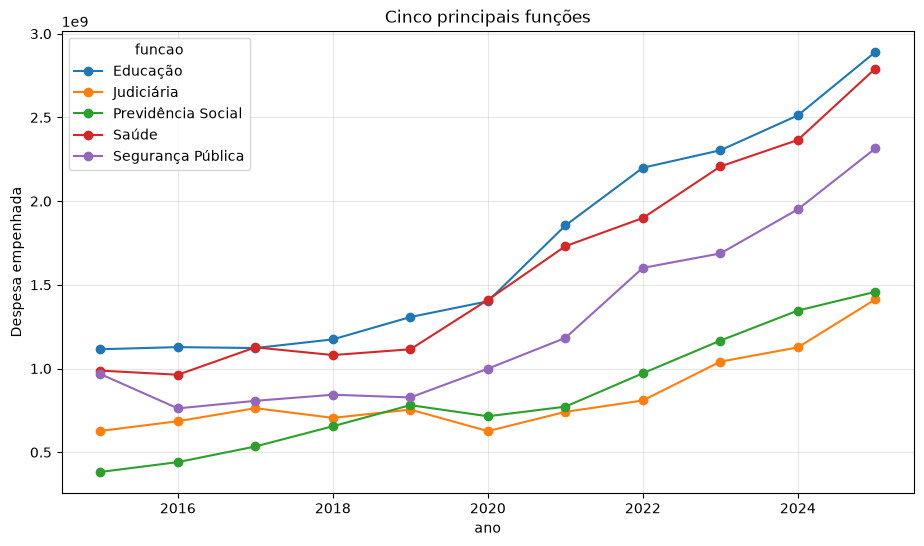

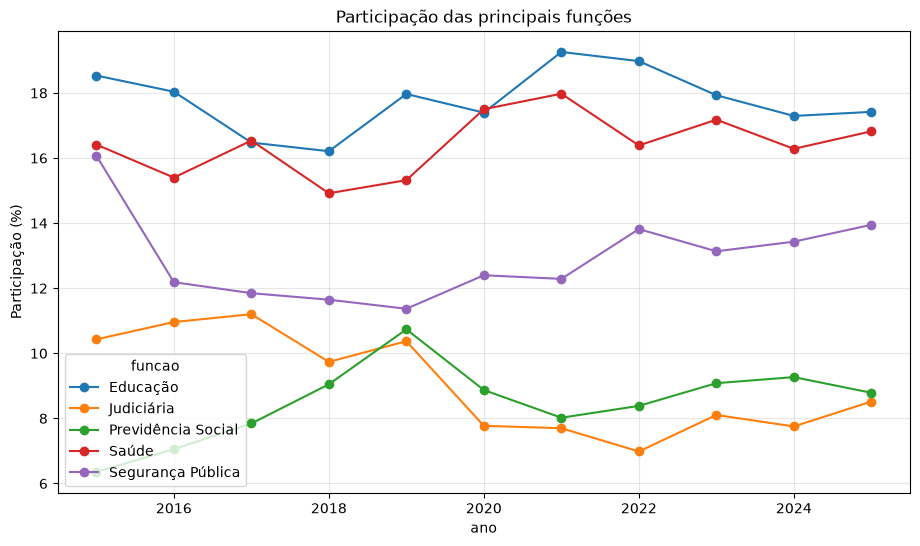

In [3]:
ranking_consolidado = funcao_ano.groupby(["codigo_funcao", "funcao"], as_index=False)["despesa"].sum().rename(columns={"despesa":"despesa_periodo"}).sort_values("despesa_periodo", ascending=False)
funcao_ano["ranking_ano"] = funcao_ano.groupby("ano")["despesa"].rank(method="first", ascending=False)
top5_ano = funcao_ano.loc[funcao_ano["ranking_ano"] <= 5].sort_values(["ano", "ranking_ano"])
principais = ranking_consolidado.head(5)["funcao"].tolist()
serie_principais = funcao_ano.loc[funcao_ano["funcao"].isin(principais)]
display(top5_ano[["ano", "ranking_ano", "funcao", "despesa"]])
display(ranking_consolidado.head(10))
serie_principais.pivot(index="ano", columns="funcao", values="despesa").plot(marker="o", figsize=(11, 6), title="Cinco principais funções")
plt.ylabel("Despesa empenhada"); plt.grid(alpha=0.3); plt.show()
serie_principais.pivot(index="ano", columns="funcao", values="participacao_pct").plot(marker="o", figsize=(11, 6), title="Participação das principais funções")
plt.ylabel("Participação (%)"); plt.grid(alpha=0.3); plt.show()

In [4]:
def serie_funcao(codigo, nome):
    resultado = funcao_ano.loc[funcao_ano["codigo_funcao"] == codigo].copy()
    if resultado.empty:
        print(f"Aviso: {nome} não encontrada.")
    return resultado

def resumo_setorial(serie):
    resumo = serie[["ano","despesa","participacao_pct"]].sort_values("ano").copy()
    resumo["crescimento_anual_pct"] = 100 * resumo["despesa"].pct_change()
    if not resumo.empty:
        resumo["crescimento_acumulado_pct"] = 100 * (resumo["despesa"] / resumo["despesa"].iloc[0] - 1)
    return resumo

saude = serie_funcao("10", "Saúde")
educacao = serie_funcao("12", "Educação")
saude_resumo = resumo_setorial(saude)
educacao_resumo = resumo_setorial(educacao)
display(saude_resumo); display(educacao_resumo)

,ano,despesa,participacao_pct,crescimento_anual_pct,crescimento_acumulado_pct
77,2015,"987,660,045.25",16.41,NaN,0.00
78,2016,"962,922,868.23",15.40,-2.50,-2.50
79,2017,"1,126,660,696.19",16.54,17.00,14.07
80,2018,"1,080,541,636.03",14.92,-4.09,9.40
81,2019,"1,114,959,955.91",15.32,3.19,12.89
82,2020,"1,410,203,085.43",17.50,26.48,42.78
83,2021,"1,730,874,743.74",17.98,22.74,75.25
84,2022,"1,899,183,629.49",16.39,9.72,92.29
85,2023,"2,207,076,339.19",17.18,16.21,123.47
86,2024,"2,365,352,116.56",16.28,7.17,139.49


,ano,despesa,participacao_pct,crescimento_anual_pct,crescimento_acumulado_pct
95,2015,"1,115,301,040.61",18.53,NaN,0.00
96,2016,"1,127,932,799.07",18.04,1.13,1.13
97,2017,"1,122,455,923.41",16.47,-0.49,0.64
98,2018,"1,174,121,119.68",16.21,4.60,5.27
99,2019,"1,307,675,883.80",17.97,11.37,17.25
100,2020,"1,401,668,722.57",17.39,7.19,25.68
101,2021,"1,854,537,776.53",19.26,32.31,66.28
102,2022,"2,199,369,792.91",18.98,18.59,97.20
103,2023,"2,303,726,595.59",17.93,4.74,106.56
104,2024,"2,512,152,207.20",17.29,9.05,125.24


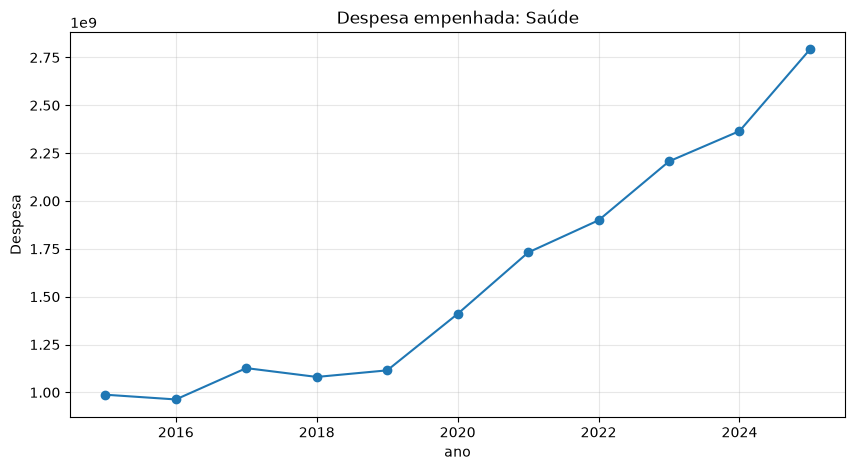

Saúde: maior crescimento anual


,ano,crescimento_anual_pct
82,2020,26.48
83,2021,22.74
87,2025,18.03


Saúde: anos de redução


,ano,crescimento_anual_pct
78,2016,-2.50
80,2018,-4.09


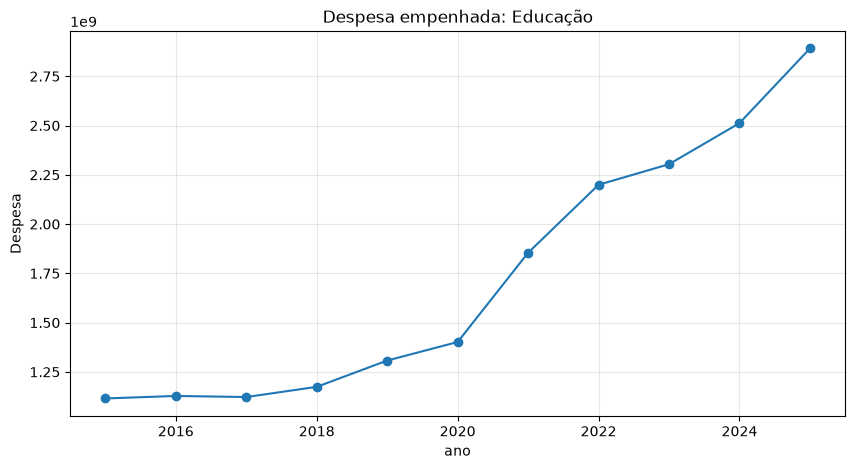

Educação: maior crescimento anual


,ano,crescimento_anual_pct
101,2021,32.31
102,2022,18.59
105,2025,15.08


Educação: anos de redução


,ano,crescimento_anual_pct
97,2017,-0.49


In [5]:
for dados, nome in [(saude_resumo, "Saúde"), (educacao_resumo, "Educação")]:
    if not dados.empty:
        dados.plot(x="ano", y="despesa", marker="o", figsize=(10,5), legend=False, title=f"Despesa empenhada: {nome}")
        plt.ylabel("Despesa"); plt.grid(alpha=0.3); plt.show()
        print(f"{nome}: maior crescimento anual")
        display(dados.nlargest(3, "crescimento_anual_pct")[["ano","crescimento_anual_pct"]])
        print(f"{nome}: anos de redução")
        display(dados.loc[dados["crescimento_anual_pct"] < 0, ["ano","crescimento_anual_pct"]])

## 7. Subfunções de Saúde e Educação

As subfunções são obtidas automaticamente pelo código inicial da classificação. A participação é calculada dentro da respectiva função em cada ano.

In [6]:
df_sub = df_analise.loc[df_analise["nivel"] == "Subfunção"].copy()
df_sub = df_sub.loc[~df_sub["conta"].str.contains("Intraorçamentárias", case=False, na=False)]
sub_ano = df_sub.groupby(["ano","codigo_funcao","codigo_subfuncao","subfuncao"], as_index=False)["valor"].sum().rename(columns={"valor":"despesa"})

def preparar_subfuncoes(codigo, nome):
    dados = sub_ano.loc[sub_ano["codigo_funcao"] == codigo].copy()
    dados["participacao_pct"] = 100 * dados["despesa"] / dados.groupby("ano")["despesa"].transform("sum")
    extremos = dados.pivot_table(index=["codigo_subfuncao","subfuncao"], columns="ano", values="despesa", aggfunc="sum").reset_index()
    if not extremos.empty:
        extremos = extremos.rename(columns={ANO_INICIAL:"valor_2015", ANO_FINAL:"valor_2025"})
        extremos["crescimento_2015_2025_pct"] = 100 * (extremos["valor_2025"] / extremos["valor_2015"] - 1)
        p = dados.pivot_table(index=["codigo_subfuncao","subfuncao"], columns="ano", values="participacao_pct", aggfunc="sum").reset_index().rename(columns={ANO_INICIAL:"participacao_2015", ANO_FINAL:"participacao_2025"})
        extremos = extremos.merge(p, on=["codigo_subfuncao","subfuncao"], how="left")
        extremos["variacao_participacao_p.p."] = extremos["participacao_2025"] - extremos["participacao_2015"]
    print(f"{nome}: {dados['subfuncao'].nunique()} subfunções")
    return dados, extremos

sub_saude, comparacao_sub_saude = preparar_subfuncoes("10", "Saúde")
sub_educacao, comparacao_sub_educacao = preparar_subfuncoes("12", "Educação")
display(sub_saude)
display(comparacao_sub_saude)
display(sub_educacao)
display(comparacao_sub_educacao)

Saúde: 7 subfunções
Educação: 8 subfunções


,ano,codigo_funcao,codigo_subfuncao,subfuncao,despesa,participacao_pct
23,2015,10,301,Atenção Básica,"101,255,976.29",10.25
24,2015,10,302,Assistência Hospitalar e Ambulatorial,"151,397,562.83",15.33
25,2015,10,303,Suporte Profilático e Terapêutico,"37,664,716.91",3.81
26,2015,10,304,Vigilância Sanitária,"1,459,521.73",0.15
27,2015,10,305,Vigilância Epidemiológica,"6,092,259.35",0.62
...,...,...,...,...,...,...
706,2025,10,301,Atenção Básica,"57,514,194.78",2.07
707,2025,10,302,Assistência Hospitalar e Ambulatorial,"1,695,766,658.56",60.96
708,2025,10,303,Suporte Profilático e Terapêutico,"20,254,780.71",0.73
709,2025,10,304,Vigilância Sanitária,"1,176,242.64",0.04


ano,codigo_subfuncao,subfuncao,valor_2015,2016_x,2017_x,2018_x,2019_x,2020_x,2021_x,2022_x,2023_x,2024_x,valor_2025,crescimento_2015_2025_pct,participacao_2015,2016_y,2017_y,2018_y,2019_y,2020_y,2021_y,2022_y,2023_y,2024_y,participacao_2025,variacao_participacao_p.p.
0,122,Administração Geral,NaN,"598,456,413.50","652,823,784.48","571,372,460.44","570,533,952.56","610,383,807.19","646,107,387.00","817,792,501.84","931,852,944.35","984,398,437.15","995,578,879.28",NaN,NaN,62.15,58.32,53.03,51.24,43.29,37.35,43.16,42.35,41.76,35.79,NaN
1,301,Atenção Básica,"101,255,976.29","51,323,003.25","85,573,200.56","73,509,788.91","94,355,697.31","52,472,406.18","108,286,712.33","95,400,145.29","113,881,886.00","52,621,825.76","57,514,194.78",-43.20,10.25,5.33,7.64,6.82,8.47,3.72,6.26,5.03,5.18,2.23,2.07,-8.18
2,302,Assistência Hospitalar e Ambulatorial,"151,397,562.83","290,654,533.51","366,754,983.61","416,266,601.64","439,627,314.59","737,738,340.14","941,857,896.87","961,444,939.35","1,103,654,350.19","1,292,381,220.35","1,695,766,658.56","1,020.08",15.33,30.18,32.76,38.64,39.48,52.32,54.45,50.74,50.16,54.82,60.96,45.63
3,303,Suporte Profilático e Terapêutico,"37,664,716.91","9,721,821.28","7,691,777.38","12,270,986.54","6,226,020.55","7,111,757.00","17,716,686.65","10,576,505.86","20,830,820.76","16,735,772.05","20,254,780.71",-46.22,3.81,1.01,0.69,1.14,0.56,0.50,1.02,0.56,0.95,0.71,0.73,-3.09
4,304,Vigilância Sanitária,"1,459,521.73","1,052,671.97","2,086,791.75","602,700.04",NaN,"105,000.00","721,115.28","924,071.37","1,146,718.33","1,200,167.48","1,176,242.64",-19.41,0.15,0.11,0.19,0.06,NaN,0.01,0.04,0.05,0.05,0.05,0.04,-0.11
5,305,Vigilância Epidemiológica,"6,092,259.35","3,315,045.93","4,459,084.12","3,332,034.13","2,743,095.14","2,153,356.65","15,086,178.38","8,674,579.53","29,013,719.05","10,174,110.41","11,319,154.59",85.80,0.62,0.34,0.40,0.31,0.25,0.15,0.87,0.46,1.32,0.43,0.41,-0.21
6,999,Demais Subfunções Saúde,"689,790,008.14","8,399,378.79",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.84,0.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,ano,codigo_funcao,codigo_subfuncao,subfuncao,despesa,participacao_pct
30,2015,12,361,Ensino Fundamental,"3,920,009.93",0.35
31,2015,12,362,Ensino Médio,"1,546,103.92",0.14
32,2015,12,363,Ensino Profissional,"571,998.45",0.05
33,2015,12,366,Educação de Jovens e Adultos,"229,763.58",0.02
34,2015,12,367,Educação Especial,"52,820.00",0.00
...,...,...,...,...,...,...
713,2025,12,361,Ensino Fundamental,"1,311,152,762.55",45.44
714,2025,12,362,Ensino Médio,"853,487,151.80",29.58
715,2025,12,363,Ensino Profissional,"29,017,993.43",1.01
716,2025,12,366,Educação de Jovens e Adultos,"174,151,247.65",6.04


ano,codigo_subfuncao,subfuncao,valor_2015,2016_x,2017_x,2018_x,2019_x,2020_x,2021_x,2022_x,2023_x,2024_x,valor_2025,crescimento_2015_2025_pct,participacao_2015,2016_y,2017_y,2018_y,2019_y,2020_y,2021_y,2022_y,2023_y,2024_y,participacao_2025,variacao_participacao_p.p.
0,122,Administração Geral,NaN,"294,839,533.74","309,898,781.75","301,822,544.88","290,263,232.31","238,679,132.61","254,440,184.20","407,548,321.01","464,614,899.25","325,303,407.22","330,651,785.33",NaN,NaN,26.14,28.04,25.83,22.32,17.29,14.49,18.96,20.99,12.98,11.46,NaN
1,361,Ensino Fundamental,"3,920,009.93","2,408,592.71","361,646,150.83","375,084,185.81","409,882,359.80","496,213,088.60","696,601,446.66","742,337,792.35","759,276,675.60","1,197,212,076.70","1,311,152,762.55","33,347.69",0.35,0.21,32.73,32.10,31.52,35.94,39.66,34.53,34.30,47.77,45.44,45.09
2,362,Ensino Médio,"1,546,103.92","9,429,944.55","208,940,503.90","228,280,505.91","250,356,796.83","307,608,671.16","389,309,695.76","468,725,248.14","446,722,279.91","762,901,885.85","853,487,151.80","55,102.44",0.14,0.84,18.91,19.54,19.25,22.28,22.16,21.81,20.18,30.44,29.58,29.44
3,363,Ensino Profissional,"571,998.45","2,470,547.46","2,477,352.12","525,474.11","3,582,860.59","15,946,078.23","8,657,578.91","14,945,965.00","11,208,531.84","23,797,564.50","29,017,993.43","4,973.09",0.05,0.22,0.22,0.04,0.28,1.16,0.49,0.70,0.51,0.95,1.01,0.95
4,366,Educação de Jovens e Adultos,"229,763.58","182,628.79","542,882.86","493,821.87","7,176,302.28","22,297,520.15","8,215,877.25","17,296,733.31","29,173,406.46","155,456,478.98","174,151,247.65","75,695.85",0.02,0.02,0.05,0.04,0.55,1.62,0.47,0.80,1.32,6.20,6.04,6.01
5,367,Educação Especial,"52,820.00","49,940.24","345,834.68","312,361.57","1,813,952.88","2,404.62","827,249.44","2,482,782.73","426,604.18","41,648,297.04","186,997,554.76","353,927.93",0.00,0.00,0.03,0.03,0.14,0.00,0.05,0.12,0.02,1.66,6.48,6.48
6,368,Educação Básica,"1,098,650,502.39","804,510,377.43","221,161,899.01","261,826,828.84","337,285,872.36","299,776,636.54","398,524,433.88","496,197,022.48","502,054,318.39",NaN,NaN,NaN,98.51,71.33,20.01,22.41,25.94,21.71,22.69,23.08,22.68,NaN,NaN,NaN
7,999,Demais Subfunções Educação,"10,329,842.34","14,041,234.15",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.93,1.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


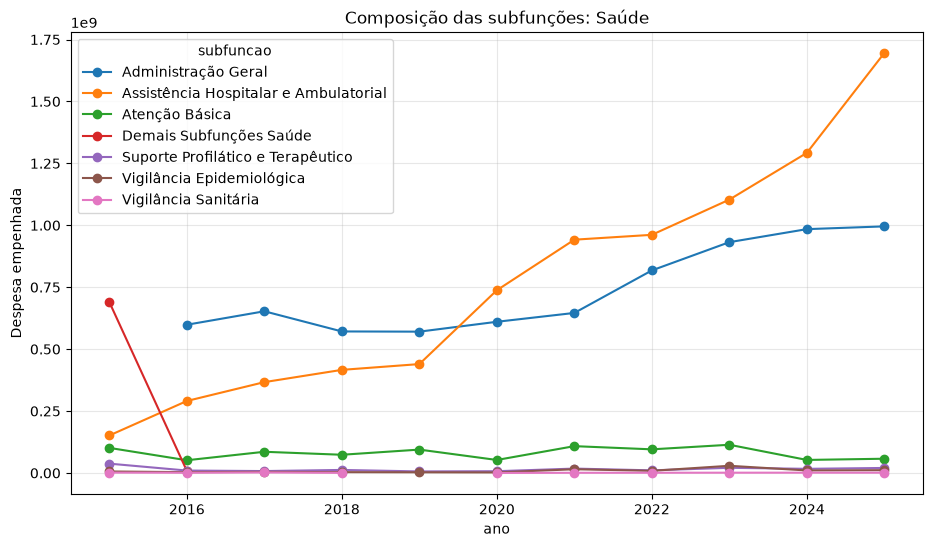

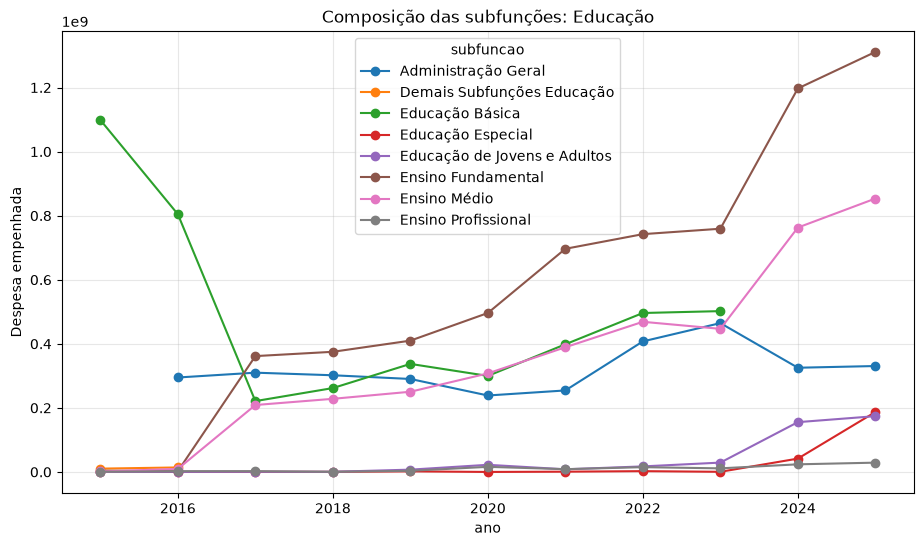

In [7]:
for dados, nome in [(sub_saude, "Saúde"), (sub_educacao, "Educação")]:
    if not dados.empty:
        dados.pivot(index="ano", columns="subfuncao", values="despesa").plot(marker="o", figsize=(11,6), title=f"Composição das subfunções: {nome}")
        plt.ylabel("Despesa empenhada"); plt.grid(alpha=0.3); plt.show()

## 8. Comparação Saúde x Educação

A soma `saude_educacao` mostra o peso conjunto das duas funções no total estadual.

,ano,despesa_total,despesa_saude,despesa_educacao,saude_educacao,pct_saude_total,pct_educacao_total,pct_saude_educacao_total
0,2015,"6,017,358,278.37","987,660,045.25","1,115,301,040.61","2,102,961,085.86",16.41,18.53,34.95
1,2016,"6,253,210,812.50","962,922,868.23","1,127,932,799.07","2,090,855,667.30",15.40,18.04,33.44
2,2017,"6,813,099,270.68","1,126,660,696.19","1,122,455,923.41","2,249,116,619.60",16.54,16.47,33.01
3,2018,"7,243,527,767.38","1,080,541,636.03","1,174,121,119.68","2,254,662,755.71",14.92,16.21,31.13
4,2019,"7,277,890,974.15","1,114,959,955.91","1,307,675,883.80","2,422,635,839.71",15.32,17.97,33.29
5,2020,"8,058,180,863.48","1,410,203,085.43","1,401,668,722.57","2,811,871,808.00",17.50,17.39,34.89
6,2021,"9,629,166,273.09","1,730,874,743.74","1,854,537,776.53","3,585,412,520.27",17.98,19.26,37.23
7,2022,"11,589,684,794.72","1,899,183,629.49","2,199,369,792.91","4,098,553,422.40",16.39,18.98,35.36
8,2023,"12,848,135,307.42","2,207,076,339.19","2,303,726,595.59","4,510,802,934.78",17.18,17.93,35.11
9,2024,"14,526,983,168.01","2,365,352,116.56","2,512,152,207.20","4,877,504,323.76",16.28,17.29,33.58


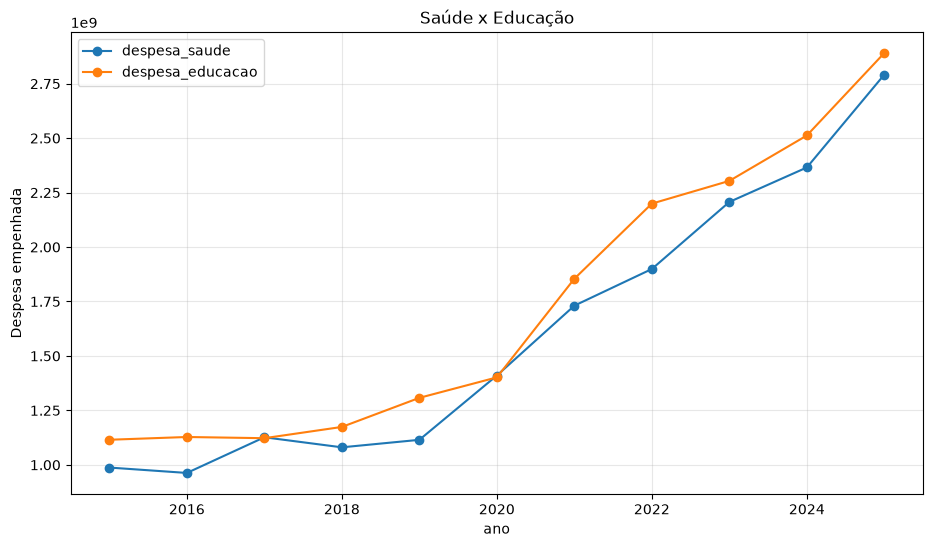

In [8]:
comparacao_setorial = totais_ano.rename(columns={"total_despesas":"despesa_total"})
for serie, coluna in [(saude, "despesa_saude"), (educacao, "despesa_educacao")]:
    comparacao_setorial = comparacao_setorial.merge(serie[["ano","despesa"]].rename(columns={"despesa":coluna}), on="ano", how="left")
comparacao_setorial[["despesa_saude","despesa_educacao"]] = comparacao_setorial[["despesa_saude","despesa_educacao"]].fillna(0)
comparacao_setorial["saude_educacao"] = comparacao_setorial["despesa_saude"] + comparacao_setorial["despesa_educacao"]
comparacao_setorial["pct_saude_total"] = 100 * comparacao_setorial["despesa_saude"] / comparacao_setorial["despesa_total"]
comparacao_setorial["pct_educacao_total"] = 100 * comparacao_setorial["despesa_educacao"] / comparacao_setorial["despesa_total"]
comparacao_setorial["pct_saude_educacao_total"] = 100 * comparacao_setorial["saude_educacao"] / comparacao_setorial["despesa_total"]
display(comparacao_setorial)
comparacao_setorial.plot(x="ano", y=["despesa_saude","despesa_educacao"], marker="o", figsize=(11,6), title="Saúde x Educação")
plt.ylabel("Despesa empenhada"); plt.grid(alpha=0.3); plt.show()

## 9. Alterações relevantes

São sinalizados: variações anuais acima de 20%, mudanças de participação acima de 2 pontos percentuais, entradas de subfunções após 2015 e ausências em 2025. Esses alertas são pontos de investigação, não conclusões causais. Alterações contábeis, classificatórias, administrativas e eventos extraordinários também podem explicar oscilações.

In [9]:
limiar_variacao, limiar_participacao = 20, 2
mudanca_part = funcao_ano.groupby("ano")["participacao_pct"].diff().abs()
alertas_funcoes = funcao_ano.loc[funcao_ano["variacao_pct"].abs().gt(limiar_variacao) | mudanca_part.gt(limiar_participacao)].copy()
alertas_funcoes["motivo"] = np.where(alertas_funcoes["variacao_pct"].abs().gt(limiar_variacao), "variação anual > 20%", "mudança de participação > 2 p.p.")

def alertas_sub(dados, area):
    anos = dados.groupby("subfuncao")["ano"].agg(["min","max"]).reset_index()
    entrada = anos.loc[anos["min"] > ANO_INICIAL].assign(tipo="entrada após 2015", area=area)
    saida = anos.loc[anos["max"] < ANO_FINAL].assign(tipo="ausência em 2025", area=area)
    return pd.concat([entrada, saida], ignore_index=True)
alertas_subfuncoes = pd.concat([alertas_sub(sub_saude, "Saúde"), alertas_sub(sub_educacao, "Educação")], ignore_index=True)
display(alertas_funcoes[["ano","funcao","variacao_pct","participacao_pct","motivo"]])
display(alertas_subfuncoes)

,ano,funcao,variacao_pct,participacao_pct,motivo
7,2022,Legislativa,21.24,3.90,variação anual > 20%
8,2023,Legislativa,21.03,4.26,variação anual > 20%
9,2024,Legislativa,24.85,4.70,variação anual > 20%
11,2015,Judiciária,NaN,10.43,mudança de participação > 2 p.p.
12,2016,Judiciária,9.22,10.96,mudança de participação > 2 p.p.
...,...,...,...,...,...
242,2021,Encargos Especiais,-5.96,4.93,mudança de participação > 2 p.p.
243,2022,Encargos Especiais,1.74,4.17,mudança de participação > 2 p.p.
244,2023,Encargos Especiais,24.04,4.67,variação anual > 20%
245,2024,Encargos Especiais,37.47,5.67,variação anual > 20%


,subfuncao,min,max,tipo,area
0,Administração Geral,2016,2025,entrada após 2015,Saúde
1,Demais Subfunções Saúde,2015,2016,ausência em 2025,Saúde
2,Administração Geral,2016,2025,entrada após 2015,Educação
3,Demais Subfunções Educação,2015,2016,ausência em 2025,Educação
4,Educação Básica,2015,2023,ausência em 2025,Educação


## 10. Valores nominais e valores reais

A coluna `valor` permanece nominal. Como não há série oficial de IPCA incluída no projeto, nenhuma taxa é inventada. A estrutura abaixo fica pronta para receber fatores oficiais por ano.

In [10]:
df["fator_ipca"] = np.nan
df["valor_real"] = np.nan
print("Valores reais não calculados: adicionar fatores IPCA oficiais antes de preencher essas colunas.")

Valores reais não calculados: adicionar fatores IPCA oficiais antes de preencher essas colunas.


# Resumo Executivo

A saída textual usa expressões como `Os dados indicam` e `A alteração merece investigação adicional`. Ela deve ser complementada por análise qualitativa antes de qualquer conclusão sobre políticas públicas.

In [11]:
def texto_setor(nome, resumo):
    if resumo.empty: return f"Não foram encontradas linhas para {nome}."
    inicial, final = resumo.iloc[0]["despesa"], resumo.iloc[-1]["despesa"]
    crescimento = 100 * (final / inicial - 1) if inicial else np.nan
    maior = resumo.loc[resumo["crescimento_anual_pct"].idxmax()]
    return f"{nome}: os dados indicam variação nominal de {crescimento:.2f}% entre 2015 e 2025; maior crescimento anual em {int(maior.ano)} ({maior.crescimento_anual_pct:.2f}%)."

print("Os dados indicam como maiores crescimentos acumulados:", ", ".join(comparacao_funcoes.nlargest(3, "crescimento_2015_2025_pct")["funcao"]))
print("Observa-se perda de participação em:", ", ".join(comparacao_funcoes.nsmallest(3, "variacao_participacao_p.p.")["funcao"]))
print(texto_setor("Saúde", saude_resumo))
print(texto_setor("Educação", educacao_resumo))
print("A alteração da composição merece investigação adicional e pode refletir fatores contábeis, administrativos ou eventos extraordinários.")
print("Os anos com mais alertas e as mudanças de subfunções são candidatos a aprofundamento qualitativo.")

Os dados indicam como maiores crescimentos acumulados: Trabalho, Cultura, Assistência Social
Observa-se perda de participação em: Administração, Segurança Pública, Judiciária
Saúde: os dados indicam variação nominal de 182.68% entre 2015 e 2025; maior crescimento anual em 2020 (26.48%).
Educação: os dados indicam variação nominal de 159.22% entre 2015 e 2025; maior crescimento anual em 2021 (32.31%).
A alteração da composição merece investigação adicional e pode refletir fatores contábeis, administrativos ou eventos extraordinários.
Os anos com mais alertas e as mudanças de subfunções são candidatos a aprofundamento qualitativo.


## 11. Exportação

As principais tabelas são salvas nas abas solicitadas. A aba `Base` inclui todos os estágios e colunas auxiliares; as demais usam o recorte de despesas empenhadas.

In [12]:
tabelas = {
    "Base": df,
    "Funcoes": funcao_ano,
    "Variacao_Funcoes": comparacao_funcoes,
    "Saude": saude_resumo,
    "Subfuncoes_Saude": sub_saude,
    "Educacao": educacao_resumo,
    "Subfuncoes_Educacao": sub_educacao,
    "Saude_x_Educacao": comparacao_setorial,
}
with pd.ExcelWriter(ARQUIVO_ANALISE, engine="openpyxl") as escritor:
    for nome, tabela in tabelas.items():
        tabela.to_excel(escritor, sheet_name=nome, index=False)
print(f"Arquivo {ARQUIVO_ANALISE} criado com sucesso.")
print("Abas:", list(tabelas))

Arquivo Analise_Despesas_RO_2015_2025.xlsx criado com sucesso.
Abas: ['Base', 'Funcoes', 'Variacao_Funcoes', 'Saude', 'Subfuncoes_Saude', 'Educacao', 'Subfuncoes_Educacao', 'Saude_x_Educacao']
